# **Tarea 1: Intervalos de Confianza para Muestras Grandes (Distribución Z)**

Cuando el tamaño de la muestra es grande ($n \geq 30$), el Teorema del Límite Central nos permite utilizar la distribución Normal Estándar para construir el intervalo de confianza (IC) para la media $\mu$:

Abra un nuevo Jupyter Notebook llamado APE_009_Intervalos.ipynb.

$$IC = \bar{x} \pm Z_{\alpha/2} \left( \frac{\sigma}{\sqrt{n}} \right)$$

1.
2. Ejecute el siguiente código para calcular un IC del 95% para el consumo energético mensual (variable simulada) de un cantón, asumiendo una muestra grande.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

# 1. Datos de la muestra (Consumo energético en kWh)
np.random.seed(42)
n_grande = 100
muestra_consumo = np.random.normal(loc=350, scale=45, size=n_grande)

# 2. Estadísticos descriptivos (Estimadores puntuales)
media_muestral = np.mean(muestra_consumo)
desv_estandar = np.std(muestra_consumo, ddof=1) # s (muestral)
error_estandar = desv_estandar / np.sqrt(n_grande) # SE

# 3. Cálculo del Intervalo de Confianza (95%)
nivel_confianza = 0.95
# loc = media muestral, scale = error estándar de la media
ic_inferior_z, ic_superior_z = norm.interval(confidence=nivel_confianza,
                                            loc=media_muestral,
                                            scale=error_estandar)

margen_error_z = (ic_superior_z - ic_inferior_z) / 2

print("--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---")
print(f"Tamaño de muestra (n): {n_grande}")
print(f"Media Muestral (Estimador puntual): {media_muestral:.2f} kWh")
print(f"Margen de Error: ±{margen_error_z:.2f} kWh")
print(f"IC al {nivel_confianza*100}%: [{ic_inferior_z:.2f}, {ic_superior_z:.2f}] kWh")


--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---
Tamaño de muestra (n): 100
Media Muestral (Estimador puntual): 345.33 kWh
Margen de Error: ±8.01 kWh
IC al 95.0%: [337.32, 353.34] kWh


# **Tarea 2: Intervalos para Muestras Pequeñas (Distribución T de Student)**

Si $n < 30$ y la varianza poblacional es desconocida, debemos utilizar la distribución $T$ de Student, la cual posee colas más "pesadas" para compensar la incertidumbre adicional, introduciendo los Grados de Libertad ($df = n - 1$).

$$IC = \bar{x} \pm t_{\alpha/2,n-1} \left( \frac{s}{\sqrt{n}} \right)$$

1. En una nueva celda, simule un escenario donde solo se pudo tomar una muestra de $n = 12$ sensores de calidad de agua.
2. Utilice `scipy.stats.t.interval(confidence, df, loc, scale)` para calcular el IC al 95%. Compare el margen de error obtenido aquí frente a usar erróneamente una distribución Z para la misma muestra pequeña.

In [ ]:
# Muestra pequeña (n=12)
n_pequena = 12
muestra_agua = np.random.normal(loc=7.2, scale=0.5, size=n_pequena) # pH del agua

media_t = np.mean(muestra_agua)
error_estandar_t = np.std(muestra_agua, ddof=1) / np.sqrt(n_pequena)
grados_libertad = n_pequena - 1

# IC usando T de Student
ic_inf_t, ic_sup_t = t.interval(confidence=0.95, df=grados_libertad,
                                loc=media_t, scale=error_estandar_t)

print(f"IC (T de Student, 95%): [{ic_inf_t:.3f}, {ic_sup_t:.3f}]")

IC (T de Student, 95%): [6.796, 7.401]


**Tarea 3: Hito del Proyecto - Estimación de la Realidad Regional (ABP)**

1. Importe su dataset regional mediante pandas.
2. Seleccione una variable cuantitativa estratégica y extraiga una muestra aleatoria de la misma (o use todos los datos si su dataset es la "muestra" de una población mayor).
3. Determine, basado en el tamaño de $n$, si debe aplicar la distribución $Z$ o la $T$ de Student.
4. Calcule y reporte el intervalo de confianza al 95%.
5. Utilice `matplotlib` para graficar la media como un punto y el intervalo de confianza como barras de error (`plt.errorbar()`).

Tamaño de la muestra (n): 8757
Media (μ estimada): $166.63
Intervalo de Confianza al 95%: [$164.26, $169.01]


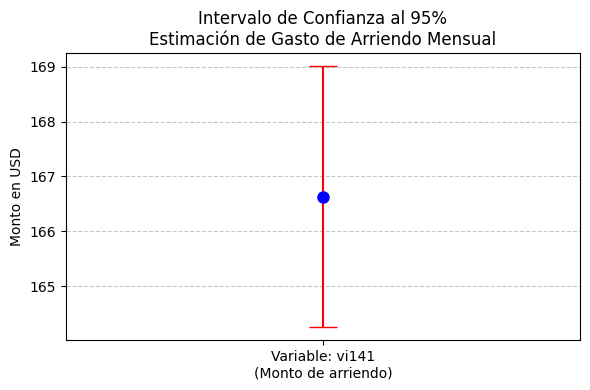

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Importe su dataset regional mediante pandas
# Usamos el separador de punto y coma según el formato de la ENEMDU
df = pd.read_csv('enemdu_vivienda_hogar_2026_02.csv', sep=';')

# Limpieza: Excluimos el valor 999999 que representa valores nulos/no respuesta
df_clean = df[df['vi141'] != 999999]

# 2. Seleccione una variable cuantitativa (vi141: pago de arriendo)
# Como la base de datos es una encuesta, asumimos todo el dataframe como la "muestra"
data = df_clean['vi141']
n = len(data)

# 3. Determinar distribución (Z o T)
# Al ser n = 8757 (n >= 30), procedemos a usar la distribución Z.

# 4. Calcule y reporte el intervalo de confianza al 95%
media = data.mean()
desviacion = data.std(ddof=1) # Desviación estándar muestral
nivel_confianza = 0.95
alfa = 1 - nivel_confianza

# Valor crítico Z
z_critico = stats.norm.ppf(1 - alfa/2)

# Margen de error e Intervalo
margen_error = z_critico * (desviacion / np.sqrt(n))
limite_inferior = media - margen_error
limite_superior = media + margen_error

print(f"Tamaño de la muestra (n): {n}")
print(f"Media (\u03bc estimada): ${media:.2f}")
print(f"Intervalo de Confianza al 95%: [${limite_inferior:.2f}, ${limite_superior:.2f}]")

plt.figure(figsize=(6, 4))

# Se grafica usando errorbar
plt.errorbar(x="Variable: vi141\n(Monto de arriendo)",
             y=media,
             yerr=margen_error,
             fmt='o',        # formato de punto para la media
             color='blue',   # color del punto
             ecolor='red',   # color de las barras de error
             capsize=10,     # tamaño de las "tapas" de las barras
             markersize=8)   # tamaño del punto central

plt.ylabel('Monto en USD')
plt.title('Intervalo de Confianza al 95%\nEstimación de Gasto de Arriendo Mensual')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

**Tarea 4: ABI - El Impacto del Nivel de Confianza ($1 - \alpha$)**

Investigue qué sucede con la precisión de una estimación cuando exigimos mayor certeza.

1. Utilizando los datos de la muestra de la Tarea 1 ($n = 100$), cree un bucle que calcule el margen de error para los siguientes niveles de confianza: [0.80, 0.90, 0.95, 0.99].
2. Genere un gráfico de barras o líneas donde el eje X sea el "Nivel de Confianza (%)" y el eje Y sea el "Margen de Error".
3. Documente en Markdown la relación observada y argumente, desde una perspectiva de toma de decisiones, por qué el 95% es el estándar de la industria en lugar del 99%.

--- Tarea 4: Impacto del Nivel de Confianza ---
Nivel de Confianza: 80% -> Margen de Error: ±5.237 kWh
Nivel de Confianza: 90% -> Margen de Error: ±6.722 kWh
Nivel de Confianza: 95% -> Margen de Error: ±8.010 kWh
Nivel de Confianza: 99% -> Margen de Error: ±10.527 kWh


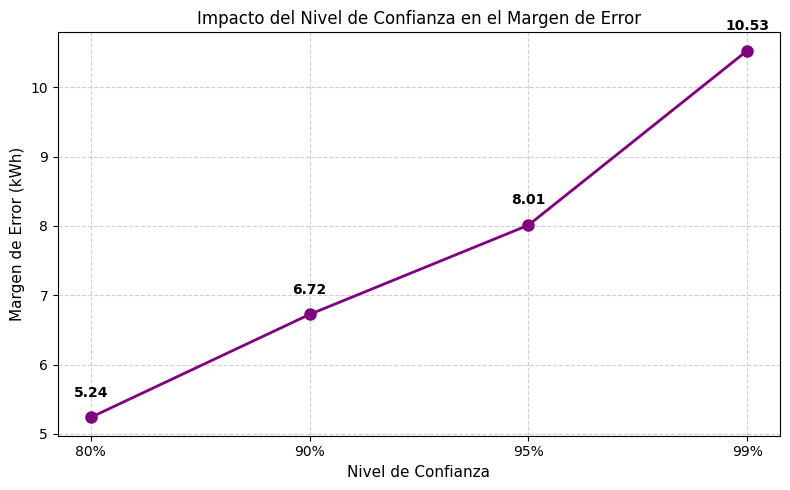

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Bucle para calcular el margen de error usando las variables de la Tarea 1
niveles_confianza = [0.80, 0.90, 0.95, 0.99]
margenes_error = []

print("--- Tarea 4: Impacto del Nivel de Confianza ---")
for conf in niveles_confianza:
    alfa = 1 - conf
    # Valor crítico Z para muestras grandes
    z_critico = stats.norm.ppf(1 - alfa/2)

    # Cálculo del Margen de Error llamando a las variables de tu Tarea 1
    margen = z_critico * (desv_estandar / np.sqrt(n_grande))
    margenes_error.append(margen)

    print(f"Nivel de Confianza: {conf*100:.0f}% -> Margen de Error: ±{margen:.3f} kWh")

# 2. Generar el gráfico de líneas
niveles_labels = [f"{int(c*100)}%" for c in niveles_confianza]

plt.figure(figsize=(8, 5))
plt.plot(niveles_labels, margenes_error, marker='o', linestyle='-', color='purple', linewidth=2, markersize=8)

# Añadir etiquetas de datos en cada punto
for i, valor in enumerate(margenes_error):
    plt.text(i, valor + 0.3, f"{valor:.2f}", ha='center', fontweight='bold')

plt.title('Impacto del Nivel de Confianza en el Margen de Error', fontsize=12)
plt.xlabel('Nivel de Confianza', fontsize=11)
plt.ylabel('Margen de Error (kWh)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Análisis: El Impacto del Nivel de Confianza

**Relación Observada:**
A partir del gráfico y los cálculos, se observa una **relación directamente proporcional** entre el nivel de confianza y el margen de error. A medida que exigimos un mayor nivel de certeza (pasando del 80% al 99%), el margen de error se incrementa significativamente. Matemáticamente, esto ocurre porque el valor crítico $Z$ crece para abarcar más área bajo la curva normal, lo que resulta en un intervalo más ancho.

**¿Por qué el 95% es el estándar de la industria frente al 99%?**
Desde una perspectiva de toma de decisiones, la elección del nivel de confianza representa un *trade-off* (compromiso) entre **certeza y precisión**:

1. **El problema del 99% (Exceso de amplitud):** Si exigimos un 99% de confianza, estamos casi absolutamente seguros de que el valor real se encuentra dentro de nuestro intervalo. Sin embargo, para garantizar esto, el intervalo se vuelve demasiado ancho. Un intervalo muy amplio (mucha imprecisión) pierde utilidad práctica. Por ejemplo, decirle a un gerente "estoy 99% seguro de que las ventas del próximo mes estarán entre \$1,000 y \$50,000" no le proporciona información útil para planificar.
2. **El equilibrio del 95%:** El 95% es el consenso estándar porque ofrece el mejor equilibrio. Nos brinda una alta probabilidad de acertar (solo nos equivocaremos por azar 1 de cada 20 veces), manteniendo un margen de error lo suficientemente estrecho como para que los datos sigan siendo precisos y accionables para la planificación, los presupuestos o la evaluación de calidad.

**1. Preguntas de Control:**

* **Defina con precisión técnica la diferencia conceptual entre una estimación puntual y una estimación por intervalos. ¿Por qué la estimación puntual por sí sola es insuficiente en ingeniería?**

**Estimación puntual:** Es el cálculo de un único valor a partir de los datos de la muestra (por ejemplo, la media muestral $\bar{x}$) que se utiliza como la "mejor suposición" del valor real del parámetro en toda la población ($\mu$).
**Estimación por intervalos:** Es el cálculo de un rango o margen de valores que, basado en la variabilidad de la muestra, tiene una probabilidad específica (el nivel de confianza) de contener el verdadero parámetro poblacional.
**Insuficiencia en la ingeniería:** Una estimación puntual carece de contexto sobre su propia precisión o margen de error. En el diseño y la ingeniería, asumir un único valor promedio para dimensionar estructuras, sistemas eléctricos o software puede llevar a fallos catastróficos o a un sobredimensionamiento ineficiente. El diseño de sistemas robustos requiere conocer los límites máximos y mínimos probables (el intervalo) para garantizar tolerancias seguras ante la incertidumbre.

* **Explique la interpretación frecuentista correcta de un Intervalo de Confianza del 95%. (Evite el error común de decir "hay un 95% de probabilidad de que $\mu$ caiga aquí").**

La interpretación correcta es sobre el *método*, no sobre el parámetro. Significa que, si repitiéramos el proceso de tomar muestras del mismo tamaño de forma independiente y calculáramos un intervalo de confianza para cada una de ellas, el 95% de esos intervalos construidos lograría "atrapar" o contener el verdadero parámetro poblacional $\mu$.

**Por qué el otro fraseo es un error:** El parámetro poblacional $\mu$ es un valor fijo y constante en la realidad; no es una variable aleatoria que se "mueve". Una vez que calculas un intervalo específico (por ejemplo, [164.26, 169.01]), el valor real $\mu$ ya está adentro (100%) o está afuera (0%). Lo que tiene el 95% de probabilidad de éxito es el procedimiento estadístico antes de extraer la muestra.

* **Al comparar las distribuciones Normal Estándar ($Z$) y la $T$ de Student, ¿qué característica visual y matemática de la campana de la $T$ de Student la hace idónea para compensar la falta de información en muestras pequeñas?**

**Característica visual y matemática:** La campana de la distribución $T$ de Student se caracteriza por tener un pico central ligeramente más bajo y, lo más importante, **colas más "pesadas" o gruesas** que la distribución Normal Estándar ($Z$). Matemáticamente, su forma depende de los Grados de Libertad ($df = n - 1$).
**Idoneidad:** Cuando la muestra es pequeña ($n < 30$), no solo ignoramos la verdadera media poblacional ($\mu$), sino también la verdadera desviación estándar poblacional ($\sigma$), viéndonos obligados a estimarla con la desviación estándar de la muestra ($s$). Esta "doble ignorancia" añade incertidumbre adicional. Las colas pesadas de la distribución $T$ penalizan esta falta de información, generando valores críticos $t$ más grandes que los $Z$, lo que matemáticamente ensancha el intervalo de confianza para evitar falsos positivos en nuestra seguridad.

* **Si en su Proyecto Integrador (Tarea 3) usted deseara reducir el Margen de Error a la mitad sin disminuir su Nivel de Confianza (manteniéndolo al 95%), ¿qué debe hacer metodológicamente con su recolección de datos ($n$)? Apóyese en la fórmula.**

Apoyándonos en la fórmula del margen de error para medias grandes:
$$E = Z_{\alpha/2} \left( \frac{\sigma}{\sqrt{n}} \right)$$

Si se desea que el nuevo margen de error sea la mitad ($\frac{E}{2}$) manteniendo estático el nivel de confianza ($Z_{\alpha/2}$) y la desviación del fenómeno ($\sigma$), la única variable que se debe alterar en la recolección de datos es $n$ (el tamaño de la muestra).

Dado que $n$ se encuentra dentro de una raíz cuadrada en el denominador, para que el resultado de la fracción se divida a la mitad, el denominador debe duplicarse. Para que $\sqrt{n}$ se convierta en $2\sqrt{n}$, necesitas multiplicar $n$ por 4, ya que $\sqrt{4n} = 2\sqrt{n}$.

* **Basado en su gráfico de la Tarea 4, ¿qué ocurre con el Intervalo de Confianza si buscamos un 100% de certeza teórica? ¿Tiene esto alguna utilidad analítica real para su proyecto en Loja?**

Basado en la progresión demostrada en la Tarea 4, si se busca una certeza del 100% ($\alpha = 0$), el valor crítico $Z$ tiende a infinito ($\infty$). En consecuencia, el margen de error también se vuelve infinito, resultando en un intervalo de $[-\infty, +\infty]$.

**Utilidad en la realidad:** Este resultado carece absolutamente de utilidad analítica. Para un análisis regional socioeconómico, afirmar con un 100% de seguridad que el promedio de ingresos o consumo eléctrico en Loja está "entre cero y el infinito" no proporciona ningún marco referencial válido. La toma de decisiones requiere fronteras delimitadas, por lo que es preferible asumir un 5% de riesgo de error (usando el 95% de confianza) para obtener un rango estrecho, procesable y accionable.